In [47]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

ev3 = pd.read_csv('../../Datasets/evaluacion3.csv')
ev2 = pd.read_csv('../../Datasets/evaluacion2.csv')

In [9]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(ev2)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,7717,0,object,7717
1,product_rating,7717,0,float64,31
2,is_best_seller,7717,0,object,11
3,is_sponsored,7717,0,object,2
4,buy_box_availability,7717,0,int64,2
5,sustainability_tags,7717,0,int64,2
6,has_coupon,7717,0,int64,2
7,discount_percentage,7717,0,float64,72
8,product_category,7717,0,object,19
9,product_segment,7717,0,object,3


In [48]:
info = info_df(ev3)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,category,7717,0,object,13
1,market_tier,7714,3,object,5
2,condition,7714,3,object,3
3,is_premium_brand,7714,3,object,3
4,tech_generation,7714,3,object,5
5,ram_gb,626,7091,float64,19
6,storage_gb,853,6864,float64,64
7,size_value,1690,6027,float64,257
8,performance_value,1283,6434,float64,243
9,power_wattage,630,7087,float64,121


In [49]:
target = 'log_original_price'
X = ev3.drop(columns=[target])
y = ev3[target]
y_euro = np.expm1(y)

In [50]:
# Extract text features
cats = X.select_dtypes(exclude=np.number).columns.tolist()

# Convert to Pandas category
for col in cats:
   X[col] = X[col].astype('category')

In [51]:
df_tipos = pd.DataFrame(X.dtypes)
df_tipos.reset_index(inplace=True)
df_tipos

,index,0
0,category,category
1,market_tier,category
2,condition,category
3,is_premium_brand,category
4,tech_generation,category
5,ram_gb,float64
6,storage_gb,float64
7,size_value,float64
8,performance_value,float64
9,power_wattage,float64


In [53]:
ev3.is_premium_brand.value_counts()

is_premium_brand
False    5587
True     2127
Name: count, dtype: int64

In [52]:
info['nuevos_tipos'] = df_tipos[0]
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores,nuevos_tipos
0,category,7717,0,object,13,category
1,market_tier,7714,3,object,5,category
2,condition,7714,3,object,3,category
3,is_premium_brand,7714,3,object,3,category
4,tech_generation,7714,3,object,5,category
5,ram_gb,626,7091,float64,19,float64
6,storage_gb,853,6864,float64,64,float64
7,size_value,1690,6027,float64,257,float64
8,performance_value,1283,6434,float64,243,float64
9,power_wattage,630,7087,float64,121,float64


In [45]:
X.dtypes

category                    category
market_tier                 category
condition                   category
is_premium_brand            category
tech_generation             category
ram_gb                       float64
storage_gb                   float64
size_value                   float64
performance_value            float64
power_wattage                float64
resolution_standard         category
cpu_gpu_tier                category
connectivity                category
brand                       category
pack_count                   float64
confidence                   float64
product_rating               float64
is_best_seller              category
is_sponsored                category
buy_box_availability           int64
sustainability_tags            int64
has_coupon                     int64
discount_percentage          float64
product_segment             category
log_purchased_last_month     float64
log_total_reviews            float64
dtype: object

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")

Dimensiones de X_train: (6173, 26)
Dimensiones de X_test:  (1544, 26)


C:\Users\USER\AppData\Local\Temp\ipykernel_22460\1541016602.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])


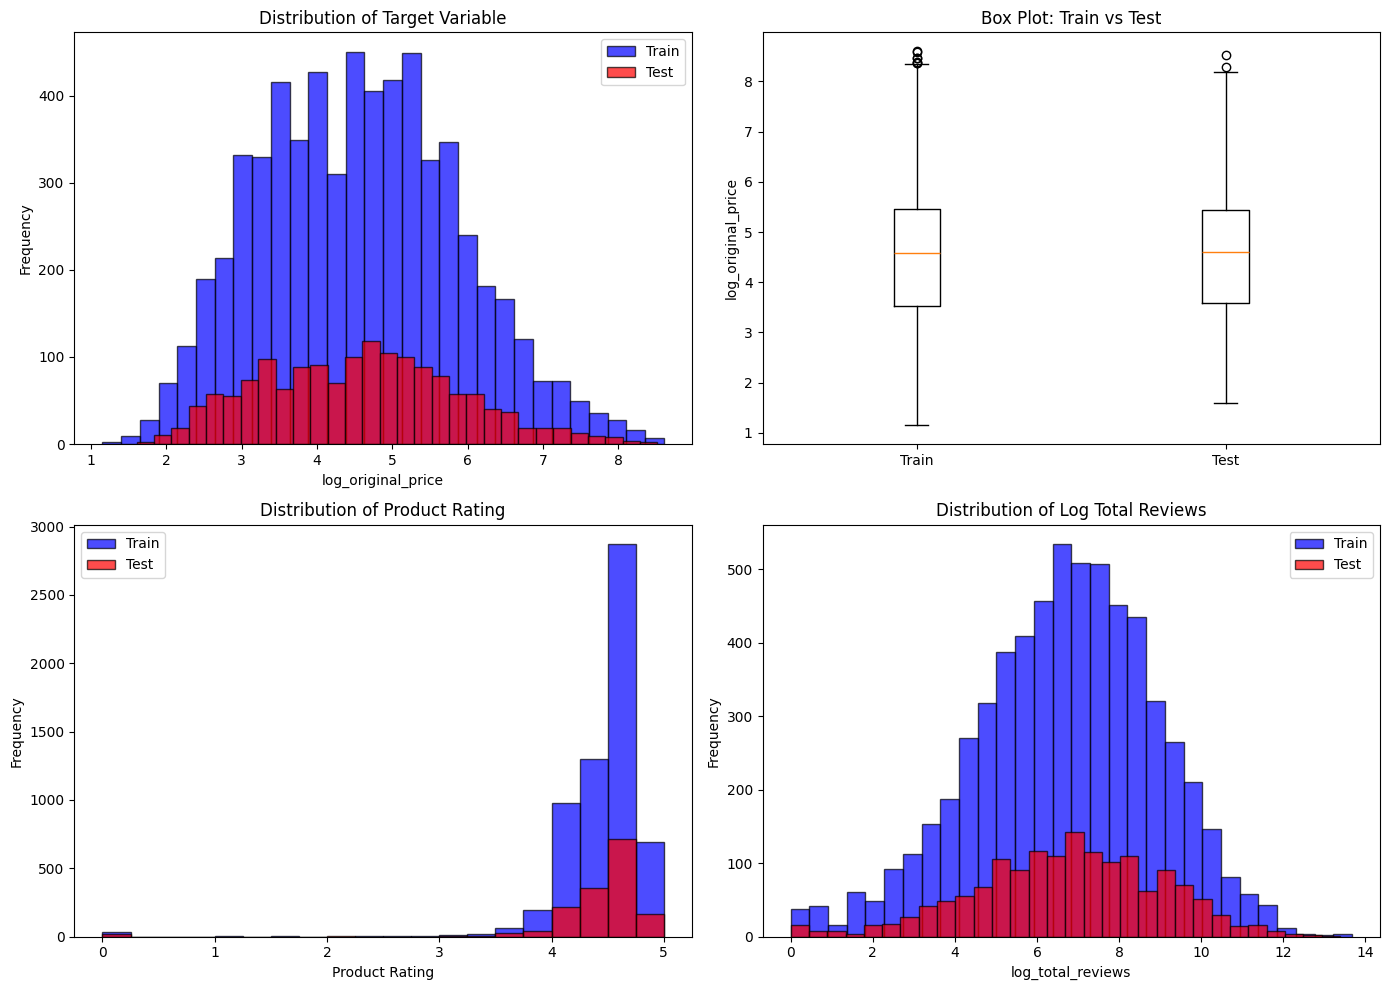

In [41]:
# Create visualizations for train and test data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of target variable
axes[0, 0].hist(y_train, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0, 0].hist(y_test, bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[0, 0].set_xlabel('log_original_price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Target Variable')
axes[0, 0].legend()

# 2. Box plot comparison
axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])
axes[0, 1].set_ylabel('log_original_price')
axes[0, 1].set_title('Box Plot: Train vs Test')

# 3. Product rating distribution
axes[1, 0].hist(X_train['product_rating'], bins=20, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 0].hist(X_test['product_rating'], bins=20, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Product Rating')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Product Rating')
axes[1, 0].legend()

# 4. Log total reviews distribution
axes[1, 1].hist(X_train['log_total_reviews'], bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 1].hist(X_test['log_total_reviews'], bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 1].set_xlabel('log_total_reviews')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Log Total Reviews')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [43]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

TypeError: object of type 'numpy.bool_' has no len()

In [ ]:
params = {
    'objective': 'reg:squarederror',  # o 'reg:absoluteerror' si hay outliers
    'eval_metric': ['rmse', 'mae'],
    'tree_method': 'hist',  # Más rápido
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'reg_alpha': 0,  # L1
    'reg_lambda': 1,  # L2
    'random_state': 42
}
evals = [(dtrain_reg, 'train'), (dtest_reg, 'val')]
model = xgb.train(
    params,
    dtrain_reg,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)
best_iteration = model.best_iteration

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 5, 10, 50]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iteration,
    tree_method='hist',
    enable_categorical=True
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

In [ ]:
best_model = random_search.best_estimator_
print(f"Mejores parámetros: {random_search.best_params_}")